<a href="https://colab.research.google.com/github/sakshi703gupta-source/BCI-Internship/blob/main/EEGNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy.io as sio

from google.colab import drive
drive.mount('/content/drive')

mci_mat = sio.loadmat('/content/drive/MyDrive/MCI.mat')
normal_mat = sio.loadmat('/content/drive/MyDrive/normal.mat')

Mounted at /content/drive


In [2]:
print("MCI keys   :", [k for k in mci_mat.keys() if not k.startswith('_')])
print("Normal keys:", [k for k in normal_mat.keys() if not k.startswith('_')])

MCI keys   : ['MCI']
Normal keys: ['normal']


In [3]:
mci_key = [k for k in mci_mat.keys() if not k.startswith('_')][0]
mci_data = mci_mat[mci_key]

print("Type        :", type(mci_data))
print("Shape       :", mci_data.shape)
print("Dtype       :", mci_data.dtype)

subj0 = mci_data[0, 0]   # try [0,0] first
print("\nSubject 0 fields:", subj0.dtype.names)
print("epoch shape :", subj0['epoch'].shape)
print("odor  shape :", subj0['odor'].shape)
print("noisy shape :", subj0['noisy'].shape)

Type        : <class 'numpy.ndarray'>
Shape       : (1, 7)
Dtype       : [('epoch', 'O'), ('odor', 'O'), ('noisy', 'O')]

Subject 0 fields: ('epoch', 'odor', 'noisy')
epoch shape : (4, 600, 120)
odor  shape : (120, 1)
noisy shape : (0, 0)


In [4]:
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
N_CHANNELS = 4
N_SAMPLES  = 600
FS         = 200
BATCH_SIZE = 16
EPOCHS     = 150
LR         = 1e-3
N_FOLDS    = 5
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")



def extract_subjects(mat_dict):
    """
    mat_dict : loaded .mat file
    Returns:
        X_list : list of arrays, one per subject, shape (trials, 1, 4, 600)
    """
    key  = [k for k in mat_dict.keys() if not k.startswith('_')][0]
    data = mat_dict[key]
    n_subjects = data.shape[1]

    X_list = []
    for i in range(n_subjects):
        subj  = data[0, i]
        epoch = subj['epoch']
        noisy = subj['noisy']

        n_trials = epoch.shape[2]


        good_mask = np.ones(n_trials, dtype=bool)
        if noisy.size > 0:
            noisy_idx = noisy.flatten().astype(int) - 1
            noisy_idx = noisy_idx[(noisy_idx >= 0) & (noisy_idx < n_trials)]
            good_mask[noisy_idx] = False

        epoch_good = epoch[:, :, good_mask]
        epoch_good = epoch_good.transpose(2, 0, 1)
        epoch_good = epoch_good[:, np.newaxis, :, :]
        X_list.append(epoch_good.astype(np.float32))
        print(f"  Subject {i+1:2d}: {epoch_good.shape[0]} trials")

    return X_list


print("\nLoading MCI subjects...")
mci_subjects = extract_subjects(mci_mat)

print("\nLoading Normal subjects...")
norm_subjects = extract_subjects(normal_mat)

# Subject-level labels
subject_labels = [1] * len(mci_subjects) + [0] * len(norm_subjects)
all_subjects   = mci_subjects + norm_subjects
n_subjects     = len(all_subjects)

print(f"\nTotal: {n_subjects} subjects  |  aMCI={len(mci_subjects)}, Healthy={len(norm_subjects)}")
print(f"Total trials: {sum(x.shape[0] for x in all_subjects)}")


# EEGNET

class EEGNet(nn.Module):
    def __init__(self, n_classes=2, C=4, T=600, F1=8, D=2, F2=16,
                 dropout=0.5, fs=200):
        super().__init__()
        half_fs = fs // 2

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, half_fs),
                      padding=(0, half_fs // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, kernel_size=(C, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.Conv2d(F2, F2, kernel_size=1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, C, T)
            out   = self.block2(self.block1(dummy))
            fc_in = out.numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fc_in, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.block2(self.block1(x)))



# HELPERS

def normalize(X_train, X_test):
    """Z-score per channel; fit on train only."""
    X_train, X_test = X_train.copy(), X_test.copy()
    for ch in range(X_train.shape[2]):
        flat  = X_train[:, 0, ch, :].reshape(-1, 1)
        sc    = StandardScaler().fit(flat)
        n_tr  = X_train.shape[0]
        n_te  = X_test.shape[0]
        X_train[:, 0, ch, :] = sc.transform(flat).reshape(n_tr, -1)
        X_test[:, 0, ch, :]  = sc.transform(
            X_test[:, 0, ch, :].reshape(-1, 1)).reshape(n_te, -1)
    return X_train, X_test


def make_loader(X, y, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(xb)
        correct  += (out.argmax(1) == yb).sum().item()
        total    += len(xb)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, probs, targets = [], [], []
    for xb, yb in loader:
        out  = model(xb.to(DEVICE))
        prob = torch.softmax(out, 1)[:, 1].cpu().numpy()
        preds.extend(out.argmax(1).cpu().numpy())
        probs.extend(prob)
        targets.extend(yb.numpy())
    return np.array(targets), np.array(preds), np.array(probs)



# SUBJECT-LEVEL STRATIFIED K-FOLD CV

skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
s_ids   = np.arange(n_subjects)
s_labs  = np.array(subject_labels)

fold_results = []

for fold, (tr_subjs, te_subjs) in enumerate(skf.split(s_ids, s_labs)):
    print(f"\n{'='*55}")
    print(f"  FOLD {fold+1}/{N_FOLDS}  |  "
          f"train={len(tr_subjs)} subjs, test={len(te_subjs)} subjs")

    # Concatenate trials across subjects
    X_tr = np.concatenate([all_subjects[i] for i in tr_subjs], axis=0)
    y_tr = np.concatenate([[subject_labels[i]] * all_subjects[i].shape[0]
                            for i in tr_subjs])
    X_te = np.concatenate([all_subjects[i] for i in te_subjs], axis=0)
    y_te = np.concatenate([[subject_labels[i]] * all_subjects[i].shape[0]
                            for i in te_subjs])

    X_tr, X_te = normalize(X_tr, X_te)

    train_loader = make_loader(X_tr, y_tr, shuffle=True)
    test_loader  = make_loader(X_te, y_te, shuffle=False)

    model     = EEGNet(C=N_CHANNELS, T=N_SAMPLES, fs=FS).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc, best_state = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        scheduler.step()

        if epoch % 25 == 0:
            tgt, pred, _ = evaluate(model, test_loader)
            val_acc = accuracy_score(tgt, pred)
            print(f"  Ep {epoch:3d} | loss={tr_loss:.4f} | "
                  f"tr_acc={tr_acc:.3f} | val_acc={val_acc:.3f}")
            if val_acc > best_acc:
                best_acc  = val_acc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    tgt, pred, prob = evaluate(model, test_loader)

    acc = accuracy_score(tgt, pred)
    auc = roc_auc_score(tgt, prob) if len(np.unique(tgt)) > 1 else float('nan')

    print(f"\n  ✓ Fold {fold+1}  Acc={acc:.4f}  AUC={auc:.4f}")
    print(classification_report(tgt, pred, target_names=['Healthy', 'aMCI']))
    fold_results.append(dict(fold=fold+1, acc=acc, auc=auc, y_true=tgt, y_pred=pred))


# ─────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("  FINAL SUMMARY")
print("="*55)
accs = [r['acc'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
for r in fold_results:
    print(f"  Fold {r['fold']}: Acc={r['acc']:.4f}  AUC={r['auc']:.4f}")
print(f"\n  Mean Acc : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"  Mean AUC : {np.nanmean(aucs):.4f} ± {np.nanstd(aucs):.4f}")

all_true = np.concatenate([r['y_true'] for r in fold_results])
all_pred = np.concatenate([r['y_pred'] for r in fold_results])
print(f"\n  Confusion Matrix (rows=true, cols=pred):")
print(f"  Labels: [Healthy, aMCI]")
print(f"  {confusion_matrix(all_true, all_pred)}")

Device: cpu

Loading MCI subjects...
  Subject  1: 120 trials
  Subject  2: 120 trials
  Subject  3: 121 trials
  Subject  4: 121 trials
  Subject  5: 118 trials
  Subject  6: 115 trials
  Subject  7: 117 trials

Loading Normal subjects...
  Subject  1: 74 trials
  Subject  2: 118 trials
  Subject  3: 121 trials
  Subject  4: 117 trials
  Subject  5: 107 trials
  Subject  6: 111 trials
  Subject  7: 39 trials
  Subject  8: 99 trials
  Subject  9: 111 trials
  Subject 10: 111 trials
  Subject 11: 88 trials
  Subject 12: 70 trials
  Subject 13: 102 trials
  Subject 14: 113 trials
  Subject 15: 116 trials

Total: 22 subjects  |  aMCI=7, Healthy=15
Total trials: 2329

  FOLD 1/5  |  train=17 subjs, test=5 subjs
  Ep  25 | loss=0.3775 | tr_acc=0.801 | val_acc=0.857
  Ep  50 | loss=0.3615 | tr_acc=0.821 | val_acc=0.855
  Ep  75 | loss=0.2777 | tr_acc=0.857 | val_acc=0.763
  Ep 100 | loss=0.2253 | tr_acc=0.896 | val_acc=0.869
  Ep 125 | loss=0.2351 | tr_acc=0.890 | val_acc=0.751
  Ep 150 | lo

In [8]:
pip install torchinfo

In [9]:
from torchinfo import summary

model = EEGNet(
    C=N_CHANNELS,
    T=N_SAMPLES,
    fs=FS
).to(DEVICE)

summary(
    model,
    input_size=(1,1,4,600)
)

Layer (type:depth-idx)                   Output Shape              Param #
EEGNet                                   [1, 2]                    --
├─Sequential: 1-1                        [1, 16, 1, 150]           --
│    └─Conv2d: 2-1                       [1, 8, 4, 601]            800
│    └─BatchNorm2d: 2-2                  [1, 8, 4, 601]            16
│    └─Conv2d: 2-3                       [1, 16, 1, 601]           64
│    └─BatchNorm2d: 2-4                  [1, 16, 1, 601]           32
│    └─ELU: 2-5                          [1, 16, 1, 601]           --
│    └─AvgPool2d: 2-6                    [1, 16, 1, 150]           --
│    └─Dropout: 2-7                      [1, 16, 1, 150]           --
├─Sequential: 1-2                        [1, 16, 1, 18]            --
│    └─Conv2d: 2-8                       [1, 16, 1, 151]           4,096
│    └─Conv2d: 2-9                       [1, 16, 1, 151]           256
│    └─BatchNorm2d: 2-10                 [1, 16, 1, 151]           32
│    └─ELU

In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 5874
Trainable Parameters : 5874


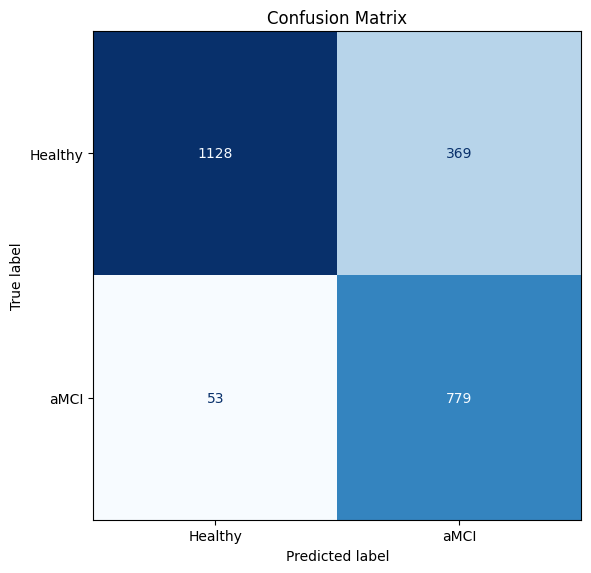

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_true, all_pred)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy","aMCI"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_true,
        all_pred,
        target_names=["Healthy","aMCI"]
    )
)

              precision    recall  f1-score   support

     Healthy       0.96      0.75      0.84      1497
        aMCI       0.68      0.94      0.79       832

    accuracy                           0.82      2329
   macro avg       0.82      0.84      0.81      2329
weighted avg       0.86      0.82      0.82      2329



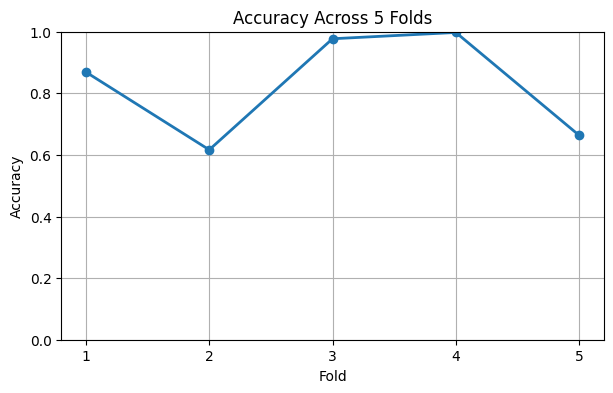

In [13]:
import matplotlib.pyplot as plt

folds = [r["fold"] for r in fold_results]
accs = [r["acc"] for r in fold_results]

plt.figure(figsize=(7,4))

plt.plot(
    folds,
    accs,
    marker="o",
    linewidth=2
)

plt.xticks(folds)

plt.ylim(0,1)

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("Accuracy Across 5 Folds")

plt.grid(True)

plt.show()

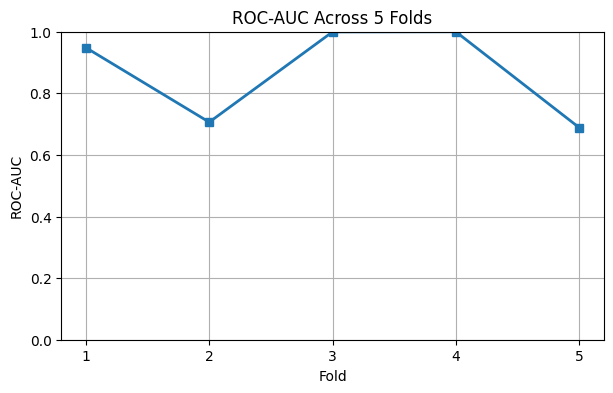

In [14]:
aucs = [r["auc"] for r in fold_results]

plt.figure(figsize=(7,4))

plt.plot(
    folds,
    aucs,
    marker="s",
    linewidth=2
)

plt.xticks(folds)

plt.ylim(0,1)

plt.xlabel("Fold")

plt.ylabel("ROC-AUC")

plt.title("ROC-AUC Across 5 Folds")

plt.grid(True)

plt.show()

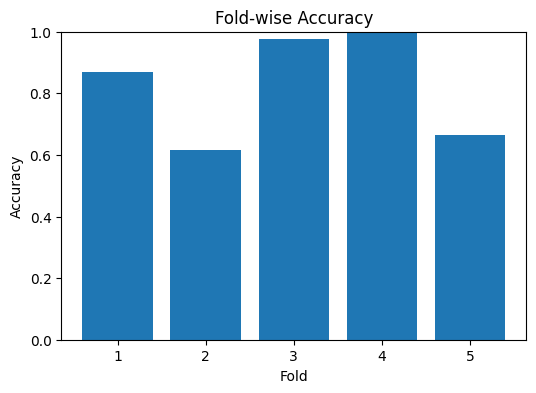

In [15]:
plt.figure(figsize=(6,4))

plt.bar(
    folds,
    accs
)

plt.ylim(0,1)

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.title("Fold-wise Accuracy")

plt.show()

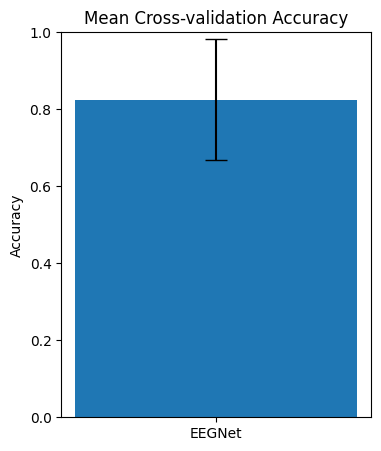

In [16]:
mean_acc = np.mean(accs)
std_acc = np.std(accs)

plt.figure(figsize=(4,5))

plt.bar(
    ["EEGNet"],
    [mean_acc],
    yerr=[std_acc],
    capsize=8
)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Mean Cross-validation Accuracy")

plt.show()